In [ ]:
import os
import cv2
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/CANCER.zip"
extract_dir = "/content/HISTO"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset extracted to:", extract_dir)

Dataset extracted to: /content/HISTO


In [ ]:
CLASS0_DIR = "/content/HISTO/CANCER/BENIGN"       # change folder name if different
CLASS1_DIR = "/content/HISTO/CANCER/MALIGNANT"    # change folder name if different

CLASS0_NAME = "benign"
CLASS1_NAME = "malignant"

OUTPUT_ROOT = "/content/drive/MyDrive/HISTO_Results"

IMG_SIZE = (300, 300)
SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs(OUTPUT_ROOT, exist_ok=True)

In [ ]:
import os
from pathlib import Path
import pandas as pd

# ============================================================
# Give correct dataset folders here
# ============================================================
# For Colab example:
BENIGN_DIR = "/content/HISTO/CANCER/BENIGN"
MALIGNANT_DIR = "/content/HISTO/CANCER/MALIGNANT"

valid_exts = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]


def collect_images(folder, label_name, label_value):
    rows = []
    folder = Path(folder)

    if not folder.exists():
        raise ValueError(f"Folder not found: {folder}")

    for p in folder.rglob("*"):
        if p.suffix.lower() in valid_exts:
            rows.append({
                "filepath": str(p),
                "label_name": label_name,
                "label": label_value
            })

    return rows


benign_rows = collect_images(BENIGN_DIR, "benign", 0)
malignant_rows = collect_images(MALIGNANT_DIR, "malignant", 1)

df = pd.DataFrame(benign_rows + malignant_rows)

print(df.head())
print("\nClass distribution:")
print(df["label_name"].value_counts())
print("\nTotal images:", len(df))

if len(df) == 0:
    raise ValueError("No images found. Check BENIGN_DIR and MALIGNANT_DIR paths.")

                                            filepath label_name  label
0  /content/HISTO/CANCER/BENIGN/SOB_B_A-14-22549G...     benign      0
1  /content/HISTO/CANCER/BENIGN/SOB_B_F-14-14134-...     benign      0
2  /content/HISTO/CANCER/BENIGN/SOB_B_F-14-21998E...     benign      0
3  /content/HISTO/CANCER/BENIGN/SOB_B_A-14-22549G...     benign      0
4  /content/HISTO/CANCER/BENIGN/SOB_B_F-14-14134E...     benign      0

Class distribution:
label_name
benign       1000
malignant    1000
Name: count, dtype: int64

Total images: 2000


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.15

train_df, temp_df = train_test_split(
    df,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=df["label"],
    random_state=SEED
)

relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:")
print(train_df["label_name"].value_counts())

print("\nValidation:")
print(val_df["label_name"].value_counts())

print("\nTest:")
print(test_df["label_name"].value_counts())

Train:
label_name
benign       700
malignant    700
Name: count, dtype: int64

Validation:
label_name
malignant    150
benign       150
Name: count, dtype: int64

Test:
label_name
malignant    150
benign       150
Name: count, dtype: int64


In [ ]:
import os
from pathlib import Path
import pandas as pd

valid_exts = [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]

def collect_images(folder, label_name, label_value):
    rows = []
    folder = Path(folder)

    if not folder.exists():
        raise ValueError(f"Folder not found: {folder}")

    for p in folder.rglob("*"):
        if p.suffix.lower() in valid_exts:
            rows.append({
                "filepath": str(p),
                "label_name": label_name,
                "label": label_value
            })

    return rows


class0_rows = collect_images(CLASS0_DIR, CLASS0_NAME, 0)
class1_rows = collect_images(CLASS1_DIR, CLASS1_NAME, 1)

df = pd.DataFrame(class0_rows + class1_rows)

print(df.head())
print("\nClass distribution:")
print(df["label_name"].value_counts())
print("\nTotal images:", len(df))

if len(df) == 0:
    raise ValueError("No images found. Check your CLASS0_DIR and CLASS1_DIR paths.")

# Optional safety check for balanced dataset
counts = df["label_name"].value_counts()
if len(counts) == 2 and counts.iloc[0] == counts.iloc[1]:
    print("\nDataset is balanced.")
else:
    print("\nWarning: Dataset is not perfectly balanced.")

                                            filepath label_name  label
0  /content/HISTO/CANCER/BENIGN/SOB_B_A-14-22549G...     benign      0
1  /content/HISTO/CANCER/BENIGN/SOB_B_F-14-14134-...     benign      0
2  /content/HISTO/CANCER/BENIGN/SOB_B_F-14-21998E...     benign      0
3  /content/HISTO/CANCER/BENIGN/SOB_B_A-14-22549G...     benign      0
4  /content/HISTO/CANCER/BENIGN/SOB_B_F-14-14134E...     benign      0

Class distribution:
label_name
benign       1000
malignant    1000
Name: count, dtype: int64

Total images: 2000

Dataset is balanced.


In [ ]:
# ============================================================
# SAVE ORIGINAL SPLIT FOLDERS
# ============================================================

def copy_split_to_folder(split_df, split_name, output_root):
    split_root = os.path.join(output_root, split_name)

    for cls in [CLASS0_NAME, CLASS1_NAME]:
        os.makedirs(os.path.join(split_root, cls), exist_ok=True)

    for _, row in split_df.iterrows():
        src = row["filepath"]
        cls = row["label_name"]

        filename = os.path.basename(src)
        dst = os.path.join(split_root, cls, filename)

        shutil.copy2(src, dst)

    return split_root


train_original_dir = copy_split_to_folder(train_df, "train_original", OUTPUT_ROOT)
val_dir = copy_split_to_folder(val_df, "validation", OUTPUT_ROOT)
test_dir = copy_split_to_folder(test_df, "test", OUTPUT_ROOT)

print("Saved original folders:")
print(train_original_dir)
print(val_dir)
print(test_dir)

Saved original folders:
/content/drive/MyDrive/HISTO_Results/train_original
/content/drive/MyDrive/HISTO_Results/validation
/content/drive/MyDrive/HISTO_Results/test


In [ ]:
# ============================================================
# BALANCED HISTO DATASET: NO CLASS BALANCING AUGMENTATION NEEDED
# ============================================================

train_balanced_dir = train_original_dir

print("Dataset is already balanced.")
print("Using original training folder as train_balanced_dir:")
print(train_balanced_dir)

print("\nTraining class distribution:")
print(train_df["label_name"].value_counts())

Dataset is already balanced.
Using original training folder as train_balanced_dir:
/content/drive/MyDrive/HISTO_Results/train_original

Training class distribution:
label_name
benign       700
malignant    700
Name: count, dtype: int64


In [ ]:
# ============================================================
# CREATE TENSORFLOW DATASETS
# ============================================================

BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_balanced_dir,
    labels="inferred",
    label_mode="binary",
    class_names=[CLASS0_NAME, CLASS1_NAME],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="binary",
    class_names=[CLASS0_NAME, CLASS1_NAME],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    class_names=[CLASS0_NAME, CLASS1_NAME],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

normalization_layer = layers.Rescaling(1.0 / 255.0)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Class names:", [CLASS0_NAME, CLASS1_NAME])

Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Class names: ['benign', 'malignant']


In [ ]:
# ============================================================
# FIXED DEPTHWISE FIR LAYER
# ============================================================

class FixedDepthwiseFIR(layers.Layer):
    def __init__(self, base_kernel, **kwargs):
        super().__init__(**kwargs)
        self.base_kernel = np.array(base_kernel, dtype=np.float32)

    def build(self, input_shape):
        C = int(input_shape[-1])
        k = self.base_kernel[:, :, np.newaxis, np.newaxis]
        k = np.tile(k, (1, 1, C, 1))

        self.depthwise_kernel = self.add_weight(
            name="fixed_dw_kernel",
            shape=k.shape,
            initializer=tf.keras.initializers.Constant(k),
            trainable=False
        )
        super().build(input_shape)

    def call(self, inputs):
        return tf.nn.depthwise_conv2d(
            inputs,
            self.depthwise_kernel,
            strides=[1, 1, 1, 1],
            padding="SAME"
        )

    def get_config(self):
        cfg = super().get_config()
        cfg["base_kernel"] = self.base_kernel.tolist()
        return cfg


GAUSSIAN_LAG_KERNEL = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16.0

LAPLACIAN_LEAD_KERNEL = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32) / 8.0


def lag_lead_compensator_block(x, T1=0.2, T2=0.1, name_prefix="ll"):
    C = int(x.shape[-1])

    identity = x

    x_smooth = FixedDepthwiseFIR(
        GAUSSIAN_LAG_KERNEL,
        name=f"{name_prefix}_fixed_gaussian_lag"
    )(x)

    lag_relu = layers.Activation(
        "relu",
        name=f"{name_prefix}_lag_relu"
    )(x_smooth)

    lag = layers.Lambda(
        lambda tensors: tensors[0] + T1 * tensors[1],
        name=f"{name_prefix}_lag_bt_inspired_modulation"
    )([x_smooth, lag_relu])

    x_edge = FixedDepthwiseFIR(
        LAPLACIAN_LEAD_KERNEL,
        name=f"{name_prefix}_fixed_laplacian_lead"
    )(x)

    neg_edge = layers.Lambda(
        lambda t: -t,
        name=f"{name_prefix}_negative_edge"
    )(x_edge)

    neg_edge_relu = layers.Activation(
        "relu",
        name=f"{name_prefix}_negative_edge_relu"
    )(neg_edge)

    lead = layers.Lambda(
        lambda tensors: tensors[0] - T2 * tensors[1],
        name=f"{name_prefix}_lead_bt_inspired_modulation"
    )([x_edge, neg_edge_relu])

    fused = layers.Concatenate(
        name=f"{name_prefix}_concat"
    )([identity, lag, lead])

    fused = layers.Conv2D(
        C,
        kernel_size=1,
        padding="same",
        use_bias=False,
        name=f"{name_prefix}_fusion_1x1"
    )(fused)

    fused = layers.BatchNormalization(
        name=f"{name_prefix}_fusion_bn"
    )(fused)

    return fused


def se_block(x, se_ratio=0.25, name_prefix="se"):
    C = int(x.shape[-1])
    r = max(1, int(C * se_ratio))

    s = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(x)
    s = layers.Reshape((1, 1, C), name=f"{name_prefix}_reshape")(s)
    s = layers.Conv2D(r, 1, activation="swish", name=f"{name_prefix}_reduce")(s)
    s = layers.Conv2D(C, 1, activation="sigmoid", name=f"{name_prefix}_expand")(s)

    return layers.Multiply(name=f"{name_prefix}_scale")([x, s])


def mbconv_with_ll(inputs, expansion, out_ch, kernel_size,
                   stride, se_ratio=0.25, drop_rate=0.0,
                   T1=0.2, T2=0.1, block_name="mb"):

    in_ch = int(inputs.shape[-1])
    exp_ch = in_ch * expansion

    x = inputs

    if expansion != 1:
        x = layers.Conv2D(
            exp_ch,
            1,
            padding="same",
            use_bias=False,
            name=f"{block_name}_expand"
        )(x)

        x = layers.BatchNormalization(name=f"{block_name}_expand_bn")(x)
        x = layers.Activation("swish", name=f"{block_name}_expand_act")(x)

    x = layers.DepthwiseConv2D(
        kernel_size,
        strides=stride,
        padding="same",
        use_bias=False,
        name=f"{block_name}_dw"
    )(x)

    x = layers.BatchNormalization(name=f"{block_name}_dw_bn")(x)
    x = layers.Activation("swish", name=f"{block_name}_dw_act")(x)

    x = lag_lead_compensator_block(
        x,
        T1=T1,
        T2=T2,
        name_prefix=f"{block_name}_ll"
    )

    x = se_block(
        x,
        se_ratio=se_ratio,
        name_prefix=f"{block_name}_se"
    )

    x = layers.Conv2D(
        out_ch,
        1,
        padding="same",
        use_bias=False,
        name=f"{block_name}_project"
    )(x)

    x = layers.BatchNormalization(name=f"{block_name}_project_bn")(x)

    if stride == 1 and in_ch == out_ch:
        if drop_rate > 0:
            x = layers.Dropout(drop_rate, name=f"{block_name}_drop")(x)
        x = layers.Add(name=f"{block_name}_skip")([inputs, x])

    return x


STAGE_CONFIGS = [
    (1,  24, 3, 3, 1),
    (6,  32, 4, 3, 2),
    (6,  48, 6, 5, 2),
    (6,  96, 9, 3, 2),
]


def build_bt_ll_efficientnetb3(
    input_shape=(300, 300, 3),
    T1=0.2,
    T2=0.1,
    drop_rate=0.0
):

    inputs = layers.Input(shape=input_shape, name="input_image")

    x = layers.Conv2D(
        40,
        kernel_size=3,
        strides=2,
        padding="same",
        use_bias=False,
        name="stem_conv"
    )(inputs)

    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.Activation("swish", name="stem_act")(x)

    for s_idx, (exp, out_ch, n_blocks, ks, stride) in enumerate(STAGE_CONFIGS):
        for b_idx in range(n_blocks):
            s = stride if b_idx == 0 else 1

            x = mbconv_with_ll(
                x,
                expansion=exp,
                out_ch=out_ch,
                kernel_size=ks,
                stride=s,
                se_ratio=0.25,
                drop_rate=drop_rate,
                T1=T1,
                T2=T2,
                block_name=f"s{s_idx+1}b{b_idx+1}"
            )

    x = layers.Conv2D(
        256,
        kernel_size=1,
        padding="same",
        use_bias=False,
        name="top_conv"
    )(x)

    x = layers.BatchNormalization(name="top_bn")(x)
    x = layers.Activation("swish", name="top_act")(x)

    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.Dropout(0.3, name="top_dropout")(x)

    outputs = layers.Dense(
        1,
        activation="sigmoid",
        name="predictions"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="BT_LL_EfficientNetB3_Inspired_ArchB"
    )

    return model

In [ ]:
model = build_bt_ll_efficientnetb3(
    input_shape=(300, 300, 3),
    T1=0.2,
    T2=0.1
)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

# ============================================================
# Training settings
# ============================================================

EPOCHS = 30

checkpoint_dir = os.path.join(OUTPUT_ROOT, "saved_model")
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "best_bt_ll_model.keras")
log_path = os.path.join(checkpoint_dir, "training_log.csv")

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(log_path)
]

# ============================================================
# Train model
# ============================================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Best model saved at:", checkpoint_path)
print("Training log saved at:", log_path)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8767 - auc: 0.9335 - loss: 0.3272 - precision: 0.8929 - recall: 0.8543   
Epoch 1: val_auc improved from None to 0.50000, saving model to /content/drive/MyDrive/HISTO_Results/saved_model/best_bt_ll_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/HISTO_Results/saved_model/best_bt_ll_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 403s 3s/step - accuracy: 0.9007 - auc: 0.9602 - loss: 0.2584 - precision: 0.9193 - recall: 0.8786 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7013 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.9421 - auc: 0.9824 - loss: 0.1650 - precision: 0.9585 - recall: 0.9231
Epoch 2: val_auc did not improve from 0.50000
88/88 ━━━━━━━━━━━━━━━━━━━━ 60s 683ms/step - accuracy: 0.9414 - auc: 0.9839 - loss: 0.1588 - precision: 0.9558 - recall: 0.9257 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7175 - val_precis

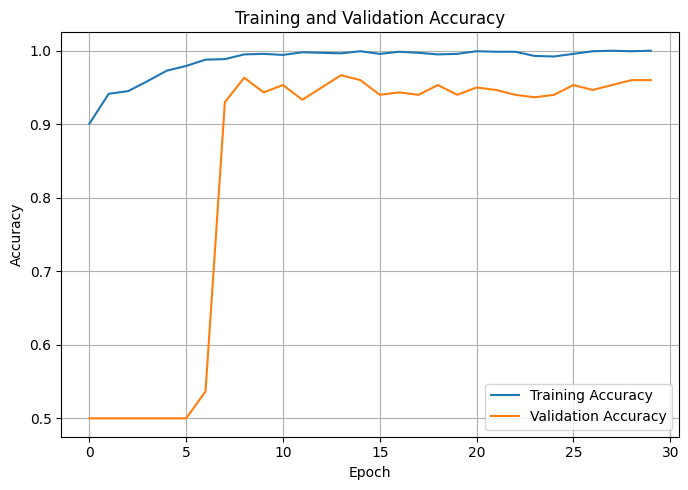

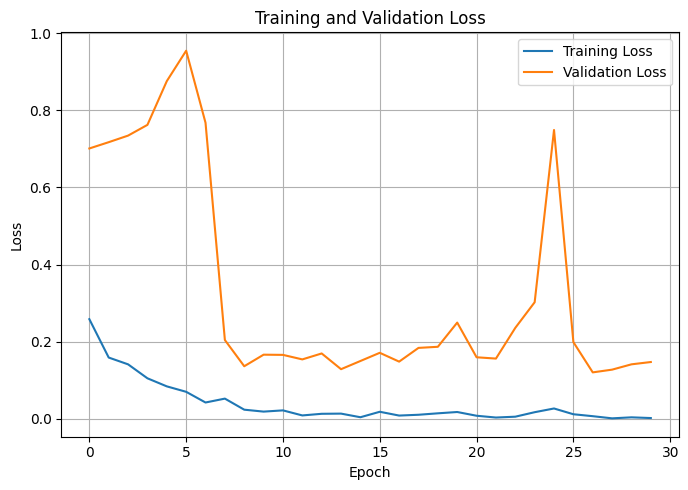

Curves saved in: /content/drive/MyDrive/HISTO_Results/training_curves


In [ ]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# ============================================================
# Training and validation curves
# ============================================================

def plot_training_curves(history, save_dir=None):
    hist = history.history

    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # ----------------------------
    # Accuracy curve
    # ----------------------------
    plt.figure(figsize=(7, 5))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_dir is not None:
        acc_path = os.path.join(save_dir, "training_validation_accuracy.png")
        plt.savefig(acc_path, dpi=300, bbox_inches="tight")

    plt.show()

    # ----------------------------
    # Loss curve
    # ----------------------------
    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_dir is not None:
        loss_path = os.path.join(save_dir, "training_validation_loss.png")
        plt.savefig(loss_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Curves saved in:", save_dir)


# Save inside your output folder
curve_save_dir = os.path.join(OUTPUT_ROOT, "training_curves")

plot_training_curves(
    history,
    save_dir=curve_save_dir
)

In [ ]:
# ============================================================
# Save history as CSV
# ============================================================

history_df = pd.DataFrame(history.history)

history_csv_path = os.path.join(OUTPUT_ROOT, "training_curves", "training_history.csv")
os.makedirs(os.path.dirname(history_csv_path), exist_ok=True)

history_df.to_csv(history_csv_path, index=False)

print("Training history saved:", history_csv_path)
history_df.head()

Training history saved: /content/drive/MyDrive/HISTO_Results/training_curves/training_history.csv


,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall
0,0.900714,0.960161,0.258379,0.919282,0.878571,0.5,0.500000,0.701254,0.0,0.0
1,0.941429,0.983891,0.158848,0.955752,0.925714,0.5,0.500000,0.717543,0.0,0.0
2,0.945000,0.987141,0.141254,0.956076,0.932857,0.5,0.500000,0.734611,0.0,0.0
3,0.958571,0.993226,0.105025,0.966570,0.950000,0.5,0.500000,0.762476,0.0,0.0
4,0.972857,0.995665,0.084101,0.976945,0.968571,0.5,0.763333,0.875931,0.0,0.0


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_val_true = []
y_val_prob = []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_val_prob.extend(probs.ravel())
    y_val_true.extend(labels.numpy().ravel())

y_val_true = np.array(y_val_true).astype(int)
y_val_prob = np.array(y_val_prob)

print("True label count:", np.bincount(y_val_true))
print("Probability min :", y_val_prob.min())
print("Probability max :", y_val_prob.max())
print("Probability mean:", y_val_prob.mean())

y_val_pred_05 = (y_val_prob >= 0.5).astype(int)

print("\nConfusion matrix at threshold 0.5:")
print(confusion_matrix(y_val_true, y_val_pred_05))

print("\nClassification report:")
print(classification_report(y_val_true, y_val_pred_05, target_names=["Benign", "Malignant"]))

print("Validation AUC:", roc_auc_score(y_val_true, y_val_prob))

True label count: [150 150]
Probability min : 3.157356e-06
Probability max : 0.99999726
Probability mean: 0.46311504

Confusion matrix at threshold 0.5:
[[150   0]
 [ 12 138]]

Classification report:
              precision    recall  f1-score   support

      Benign       0.93      1.00      0.96       150
   Malignant       1.00      0.92      0.96       150

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

Validation AUC: 0.9900888888888889


In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

thresholds = np.arange(0.10, 0.91, 0.01)

best_f1 = 0
best_threshold = 0.5

for th in thresholds:
    y_pred_th = (y_val_prob >= th).astype(int)
    f1 = f1_score(y_val_true, y_pred_th, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print("Best threshold:", best_threshold)
print("Best validation F1:", best_f1)

y_val_pred_best = (y_val_prob >= best_threshold).astype(int)

print("\nConfusion matrix at best threshold:")
print(confusion_matrix(y_val_true, y_val_pred_best))

print("\nClassification report at best threshold:")
print(classification_report(y_val_true, y_val_pred_best, target_names=["Benign", "Malignant"]))

Best threshold: 0.13
Best validation F1: 0.9627118644067797

Confusion matrix at best threshold:
[[147   3]
 [  8 142]]

Classification report at best threshold:
              precision    recall  f1-score   support

      Benign       0.95      0.98      0.96       150
   Malignant       0.98      0.95      0.96       150

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



y_true shape: (300,)
y_prob shape: (300,)
True label count: [150 150]

Selected threshold: 0.3
Predicted label count: [166 134]

Confusion Matrix:
[[150   0]
 [ 16 134]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.90      1.00      0.95       150
   Malignant       1.00      0.89      0.94       150

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

Accuracy    : 0.9466666666666667
Precision   : 1.0
Recall      : 0.8933333333333333
F1-score    : 0.9436619718309859
Specificity : 1.0
AUC         : 0.9925333333333333

Saved metrics: /content/drive/MyDrive/HISTO_Results/test_metrics.csv
Saved predictions: /content/drive/MyDrive/HISTO_Results/test_predictions.csv


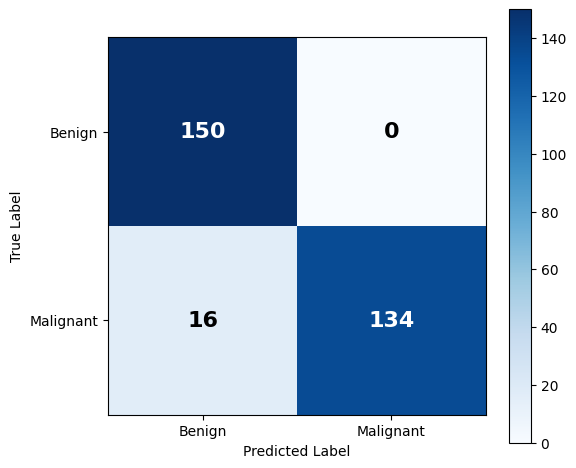

Saved confusion matrix: /content/drive/MyDrive/HISTO_Results/confusion_matrix_threshold_0.3.png


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# TEST PREDICTIONS
# ============================================================

y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs.ravel())
    y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

print("y_true shape:", y_true.shape)
print("y_prob shape:", y_prob.shape)
print("True label count:", np.bincount(y_true))


# ============================================================
# SELECT THRESHOLD
# ============================================================

# Use 0.50 for default result
# Use 0.30 only if selected from validation set or used as threshold analysis
THRESHOLD = 0.30

y_pred = (y_prob >= THRESHOLD).astype(int)

print("\nSelected threshold:", THRESHOLD)
print("Predicted label count:", np.bincount(y_pred))


# ============================================================
# CLASSIFICATION METRICS
# ============================================================

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

try:
    auc = roc_auc_score(y_true, y_prob)
except:
    auc = np.nan

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malignant"],
    zero_division=0
))

print("Accuracy    :", acc)
print("Precision   :", prec)
print("Recall      :", rec)
print("F1-score    :", f1)
print("Specificity :", specificity)
print("AUC         :", auc)


# ============================================================
# SAVE METRICS AS CSV
# ============================================================

metrics_df = pd.DataFrame({
    "Threshold": [THRESHOLD],
    "TN": [tn],
    "FP": [fp],
    "FN": [fn],
    "TP": [tp],
    "Accuracy": [acc],
    "Precision": [prec],
    "Recall": [rec],
    "F1_score": [f1],
    "Specificity": [specificity],
    "AUC": [auc]
})

metrics_save_path = os.path.join(OUTPUT_ROOT, "test_metrics.csv")
metrics_df.to_csv(metrics_save_path, index=False)

print("\nSaved metrics:", metrics_save_path)


# ============================================================
# SAVE TEST PREDICTIONS AS CSV
# ============================================================

prediction_df = pd.DataFrame({
    "true_label": y_true,
    "pred_prob": y_prob,
    "pred_label": y_pred
})

prediction_save_path = os.path.join(OUTPUT_ROOT, "test_predictions.csv")
prediction_df.to_csv(prediction_save_path, index=False)

print("Saved predictions:", prediction_save_path)


# ============================================================
# CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
#plt.title(f"Confusion Matrix - Histo\nThreshold = {THRESHOLD}")
plt.colorbar()

classes = ["Benign", "Malignant"]
plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

for i in range(2):
    for j in range(2):
        value = cm[i, j]
        text_color = "white" if value > cm.max() / 2 else "black"
        plt.text(
            j,
            i,
            value,
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=text_color
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_save_path = os.path.join(OUTPUT_ROOT, f"confusion_matrix_threshold_{THRESHOLD}.png")
plt.savefig(cm_save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix:", cm_save_path)

In [ ]:
import numpy as np

print("True label count:", np.bincount(y_true))
print("Predicted label count:", np.bincount(y_pred))

True label count: [150 150]
Predicted label count: [166 134]


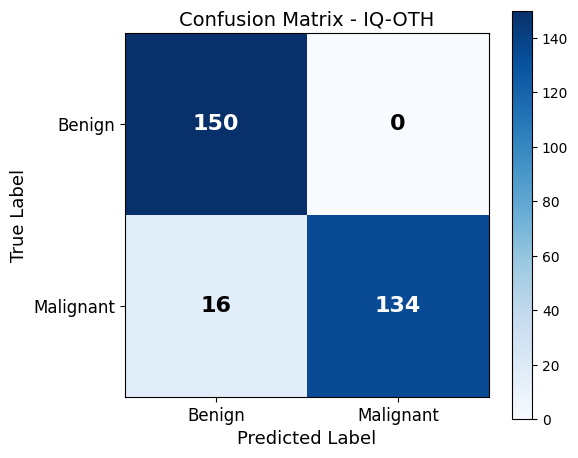

Saved: /content/drive/MyDrive/HISTO_Results/confusion_matrix_iq_oth.png


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

# Better color map
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

plt.title("Confusion Matrix - IQ-OTH", fontsize=14)
plt.colorbar()

classes = ["Benign", "Malignant"]
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, fontsize=12)
plt.yticks(tick_marks, classes, fontsize=12)

# Write values with contrasting colors
thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=16,
            fontweight="bold"
        )

plt.xlabel("Predicted Label", fontsize=13)
plt.ylabel("True Label", fontsize=13)

plt.tight_layout()

cm_path = os.path.join(OUTPUT_ROOT, "confusion_matrix_iq_oth.png")
plt.savefig(cm_path, dpi=600, bbox_inches='tight')
plt.show()

print("Saved:", cm_path)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

for th in [0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred_th = (y_prob >= th).astype(int)
    print("\nThreshold:", th)
    print(confusion_matrix(y_true, y_pred_th))
    print(classification_report(
        y_true,
        y_pred_th,
        target_names=["Benign", "Malignant"],
        zero_division=0
    ))


Threshold: 0.5
[[150   0]
 [ 19 131]]
              precision    recall  f1-score   support

      Benign       0.89      1.00      0.94       150
   Malignant       1.00      0.87      0.93       150

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300


Threshold: 0.45
[[150   0]
 [ 19 131]]
              precision    recall  f1-score   support

      Benign       0.89      1.00      0.94       150
   Malignant       1.00      0.87      0.93       150

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300


Threshold: 0.4
[[150   0]
 [ 19 131]]
              precision    recall  f1-score   support

      Benign       0.89      1.00      0.94       150
   Malignant       1.00      0.87      0.93       150

    accuracy                           0.94       300
   macro a